In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
#Load Data Set
df=pd.read_csv('haberman.csv')
df.head(3)

,30,64,1,1.1
0,30,62,3,1
1,30,65,0,1
2,31,59,2,1


In [4]:
df.columns=['Age','Year','Nodes','Survival']

In [5]:
df.head(5)

,Age,Year,Nodes,Survival
0,30,62,3,1
1,30,65,0,1
2,31,59,2,1
3,31,65,4,1
4,33,58,10,1


In [13]:
#year are 62 means 1962

In [4]:
#check shape rows and columns
df.shape

(305, 4)

In [ ]:
#check missing values
df.isnull().sum()

Age         0
Year        0
Nodes       0
Survival    0
dtype: int64

In [ ]:
#check data type
df.dtypes

Age         int64
Year        int64
Nodes       int64
Survival    int64
dtype: object

In [ ]:
#check duplicate values 
df.duplicated().value_counts()

False    288
True      17
Name: count, dtype: int64

In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 305 entries, 0 to 304
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   Age       305 non-null    int64
 1   Year      305 non-null    int64
 2   Nodes     305 non-null    int64
 3   Survival  305 non-null    int64
dtypes: int64(4)
memory usage: 9.7 KB


In [29]:
df['Survival'].value_counts()

Survival
1    224
2     81
Name: count, dtype: int64

In [31]:
df=df.replace([1,2],[0,1])

In [33]:
df['Survival'].value_counts()

Survival
0    224
1     81
Name: count, dtype: int64

In [ ]:
#Statistical summary
df.describe()

,Age,Year,Nodes,Survival
count,305.000000,305.000000,305.000000,305.000000
mean,52.531148,62.849180,3.839344,0.265574
std,10.744024,3.254078,7.283978,0.442364
min,30.000000,58.000000,0.000000,0.000000
25%,44.000000,60.000000,0.000000,0.000000
50%,52.000000,63.000000,0.000000,0.000000
75%,61.000000,66.000000,4.000000,1.000000
max,83.000000,69.000000,52.000000,1.000000


<h3>UNIVARIANT ANALYSIS</h3>

In [38]:
df['Survival'].value_counts()

Survival
0    224
1     81
Name: count, dtype: int64

In [40]:
df['Survival'].value_counts(1)

Survival
0    0.734426
1    0.265574
Name: proportion, dtype: float64

<Axes: xlabel='Survival', ylabel='count'>

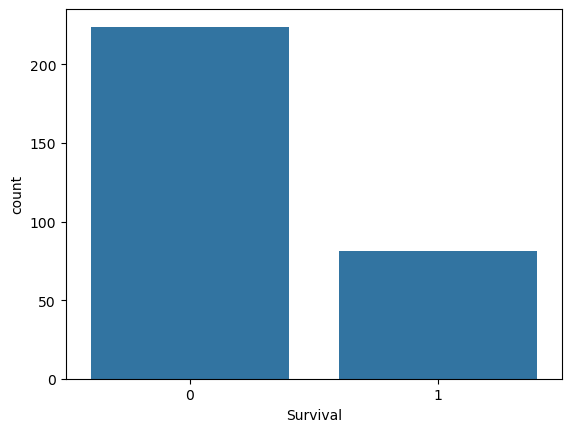

In [44]:
sns.countplot(x='Survival',data=df)

<h3>#AGE</h3>

In [47]:
df['Age'].describe()

count    305.000000
mean      52.531148
std       10.744024
min       30.000000
25%       44.000000
50%       52.000000
75%       61.000000
max       83.000000
Name: Age, dtype: float64

In [49]:
print(df.Age.skew())

0.15898611605406873


<Axes: xlabel='Age', ylabel='Count'>

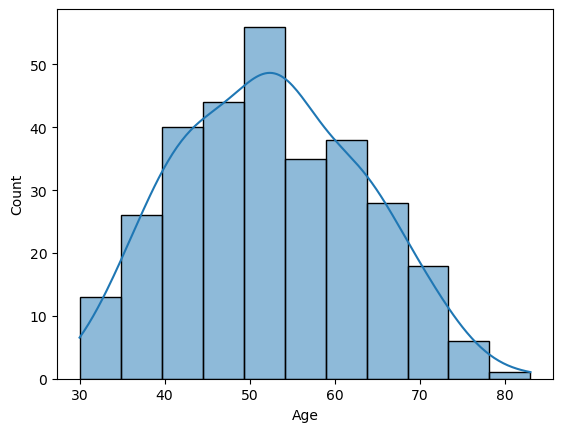

In [53]:
sns.histplot(x='Age',data=df,binwidth=5,kde=True)

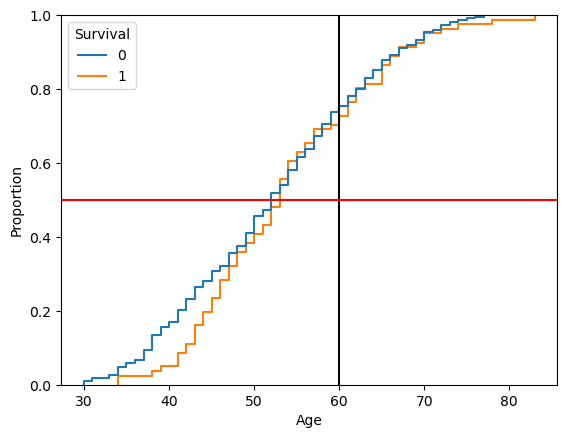

In [59]:
sns.ecdfplot(x='Age',data=df,hue='Survival')
plt.axvline(60,c='black')
plt.axhline(0.5,c='red')

<h3>Operation year</h3>

In [62]:
df['Year'].value_counts()

Year
58    36
64    30
63    30
65    28
60    28
66    28
59    27
61    26
67    25
62    23
68    13
69    11
Name: count, dtype: int64

<Axes: xlabel='Year'>

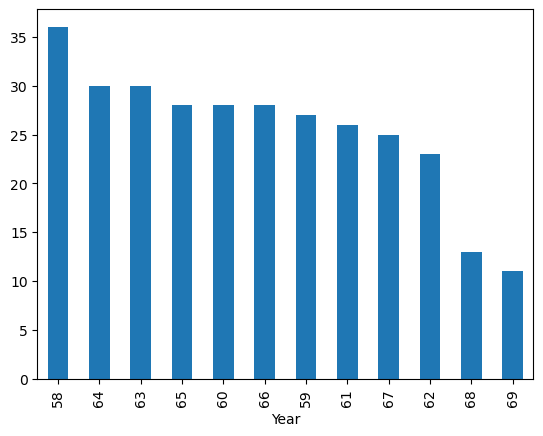

In [64]:
df['Year'].value_counts().plot(kind='bar')

<h3>lymph node</h3>

In [69]:
df['Nodes'].describe()

count    305.000000
mean       3.839344
std        7.283978
min        0.000000
25%        0.000000
50%        0.000000
75%        4.000000
max       52.000000
Name: Nodes, dtype: float64

<Axes: xlabel='Nodes'>

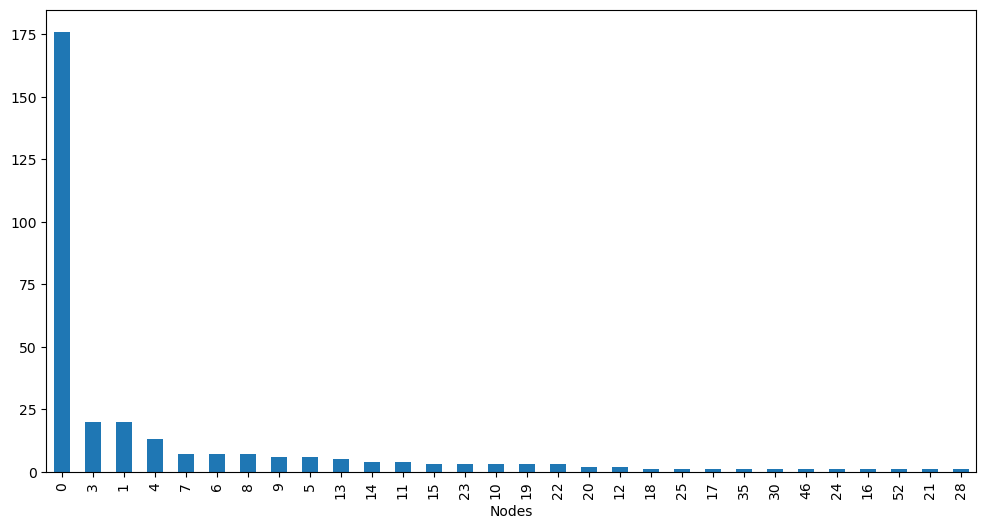

In [73]:
plt.figure(figsize=(12,6))
df['Nodes'].value_counts().plot(kind='bar')

<Axes: xlabel='Nodes', ylabel='Count'>

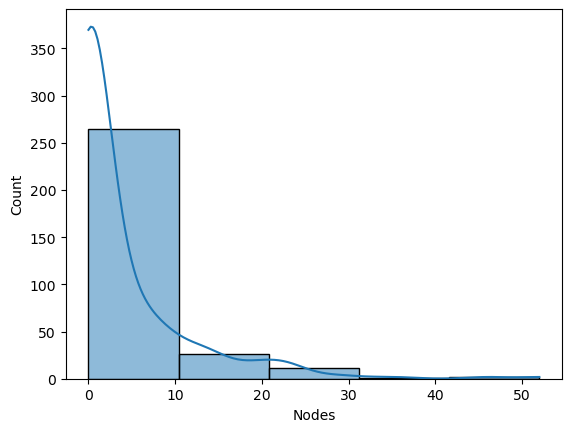

In [79]:
sns.histplot(x='Nodes',data=df,binwidth=10,kde=True)

<h3>Bivariate Analysis</h3>

In [69]:
#Nodes - Survival
#Age - Survival
#Years -Survival
#Years - Nodes
#Age - Years
#Age -Nodes
#Age -Nodes -Survival

<Axes: xlabel='Survival', ylabel='Age'>

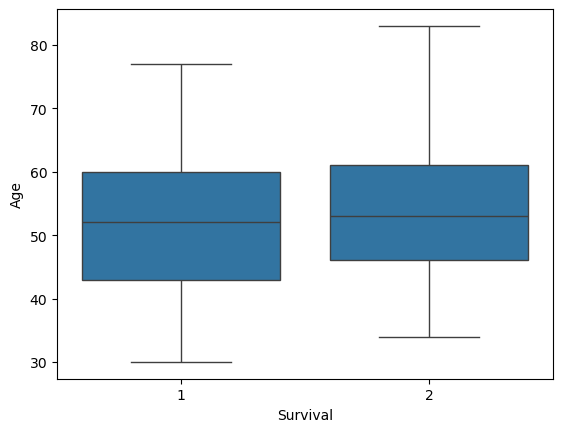

In [14]:
sns.boxplot(x='Survival',y='Age',data=df)

In [17]:
#people with age>77  will actually live lesser then  5 years()
#people with age<35  will actually live more then  5 years()


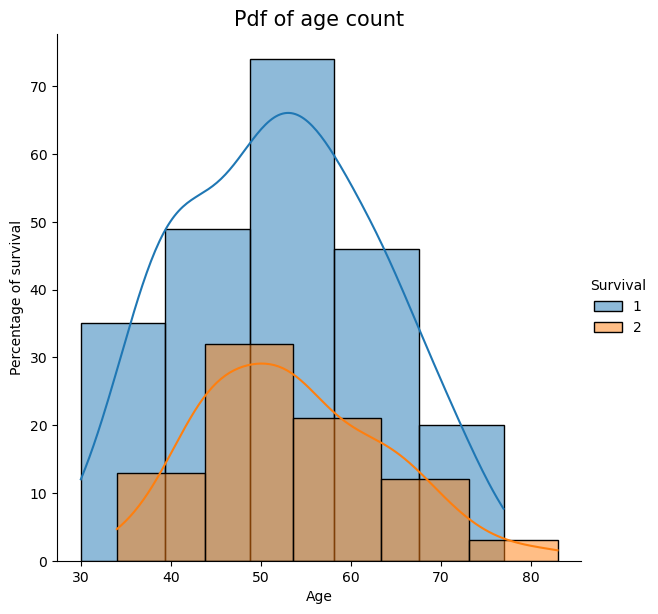

In [37]:
sns.FacetGrid(df,hue='Survival',height=6).map(sns.histplot,'Age',bins=5,kde=True).add_legend()
plt.xlabel('Age')
plt.ylabel('Percentage of survival')
plt.title('Pdf of age count',size=15)
plt.show()


In [73]:
#maximum % of people living lesser then 5 years are between 45 to 55 
#people between 30-33 years old are living more then 5 years 

In [51]:
df.groupby('Age')['Survival'].sum().sort_values(ascending=False)

Age
52    18
54    17
53    17
43    15
50    14
65    14
57    14
47    14
41    13
61    12
49    12
45    12
55    12
42    11
46    11
38    11
44    10
48    10
62    10
63     9
34     9
59     9
56     9
70     9
51     8
60     8
67     8
58     7
39     7
66     7
37     6
72     5
69     5
64     5
74     3
40     3
73     2
78     2
30     2
68     2
31     2
36     2
35     2
33     2
83     2
71     1
75     1
76     1
77     1
Name: Survival, dtype: int64

In [85]:
df.Nodes.value_counts().sort_values(ascending=False)

Nodes
0     136
1      40
3      20
2      20
4      13
7       7
6       7
8       7
9       6
5       6
13      5
14      4
11      4
10      3
15      3
23      3
19      3
22      3
20      2
12      2
21      1
52      1
30      1
16      1
24      1
46      1
18      1
35      1
17      1
25      1
28      1
Name: count, dtype: int64

In [87]:
27/176

0.1534090909090909

In [89]:
7/20

0.35

In [91]:
3/7

0.42857142857142855

In [95]:
2/7

0.2857142857142857

<Figure size 1200x600 with 0 Axes>

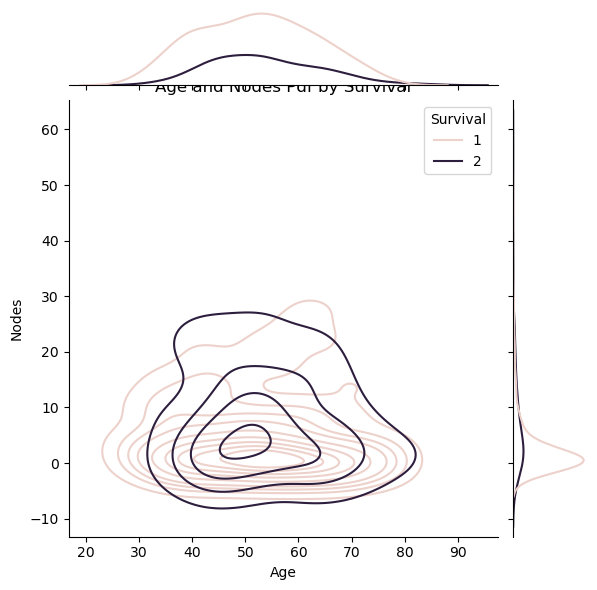

In [71]:
plt.figure(figsize=(12,6))
sns.jointplot(x='Age',y='Nodes',data=df,hue='Survival',kind='kde')
plt.title('Age and Nodes Pdf by Survival')
plt.show()


<Axes: xlabel='Survival', ylabel='Nodes'>

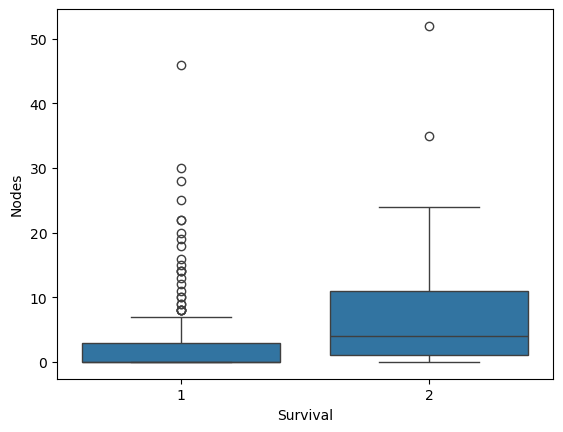

In [75]:
sns.boxplot(x='Survival',y='Nodes',data=df)

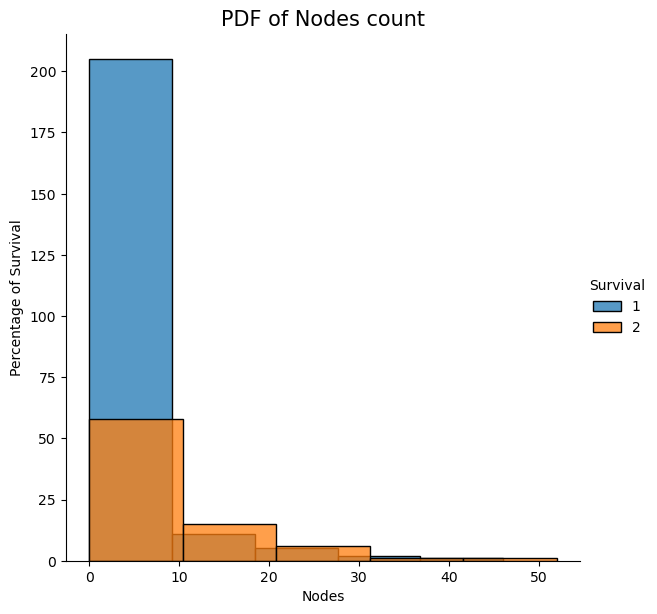

In [81]:
sns.FacetGrid(df,hue='Survival',height=6).map(sns.histplot,'Nodes',bins=5).add_legend()
plt.xlabel('Nodes')
plt.ylabel('Percentage of Survival')
plt.title('PDF of Nodes count',size=15)
plt.show()

In [83]:
#age [43-53]- and nodes [10-52] will live lesser then 5 years

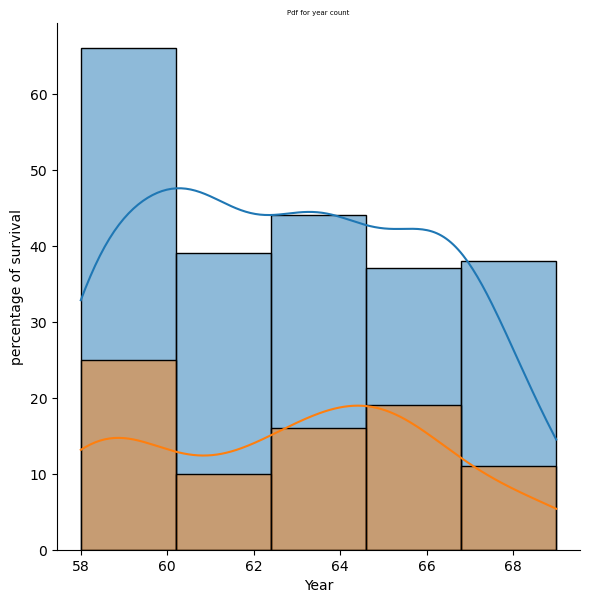

In [103]:
sns.FacetGrid(df,hue='Survival',height=6).map(sns.histplot,'Year',bins=5,kde=True)
plt.xlabel('Year')
plt.ylabel('percentage of survival')
plt.title('Pdf for year count',size=5)
plt.show()

In [105]:
df.groupby('Survival')['Year'].value_counts().unstack()

Year,58,59,60,61,62,63,64,65,66,67,68,69
Survival,,,,,,,,,,,,
1,24,18,24,23,16,22,22,15,22,21,10,7
2,12,9,4,3,7,8,8,13,6,4,3,4


In [107]:
9/20

0.45

In [109]:
#33 % people died before 5 years when operated between 1965,1966

<Figure size 1200x600 with 0 Axes>

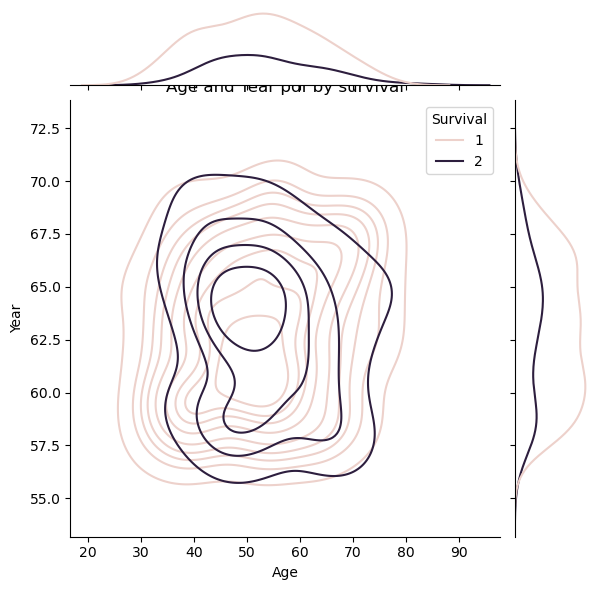

In [113]:
plt.figure(figsize=(12,6))
sns.jointplot(x='Age',y='Year',data=df,hue='Survival',kind='kde')
plt.title('Age and Year pdf by survival')
plt.show()

<h3>Multivariant Analysis</h3>

<Axes: >

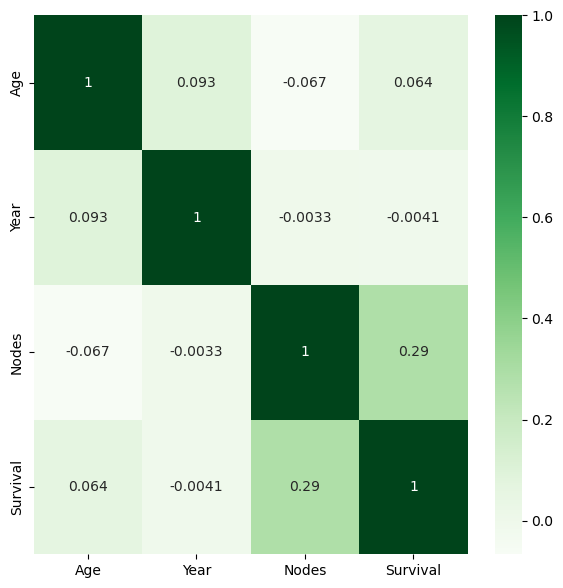

In [136]:
plt.figure(figsize=(7,7))
corr=df.corr()
sns.heatmap(corr,xticklabels=corr.columns,yticklabels=corr.columns,cmap='Greens',annot=True)

<h2>Nodes and survival as corelated by 29%</h2>